In [ ]:
import pandas as pd
import numpy as np

wf_ranges = {
    "Sugarcane": (2500, 4500),
    "Rice": (3000, 5000),
    "Banana": (3000, 4000),
    "Cotton": (2000, 3000),
    "Soybean": (1200, 1800),
    "Wheat": (1300, 2000),
    "Groundnut": (1800, 2600),
    "Jowar": (600, 1500),
    "Tur": (500, 800),
    "Maize": (600, 900),
    "Grapes": (1200, 2000),
    "Onions": (700, 1100)
}

fallback_values = {crop: round(np.mean(wf_ranges[crop]), 2) for crop in wf_ranges}

fallback_df = pd.DataFrame({
    "Crop": list(wf_ranges.keys()),
    "Min (L/kg)": [wf_ranges[c][0] for c in wf_ranges],
    "Max (L/kg)": [wf_ranges[c][1] for c in wf_ranges],
    "Calculated_Fallback (Mean L/kg)": list(fallback_values.values())
})

fallback_df.to_csv("/content/Fallback_WaterFootprint_Values.csv", index=False)

print("✅ Fallback Values Generated Successfully!\n")
display(fallback_df)

print("\n Dictionary you can use in your main code:")
print(fallback_values)


✅ Fallback Values Generated Successfully!



,Crop,Min (L/kg),Max (L/kg),Calculated_Fallback (Mean L/kg)
0,Sugarcane,2500,4500,3500.0
1,Rice,3000,5000,4000.0
2,Banana,3000,4000,3500.0
3,Cotton,2000,3000,2500.0
4,Soybean,1200,1800,1500.0
5,Wheat,1300,2000,1650.0
6,Groundnut,1800,2600,2200.0
7,Jowar,600,1500,1050.0
8,Tur,500,800,650.0
9,Maize,600,900,750.0



 Dictionary you can use in your main code:
{'Sugarcane': np.float64(3500.0), 'Rice': np.float64(4000.0), 'Banana': np.float64(3500.0), 'Cotton': np.float64(2500.0), 'Soybean': np.float64(1500.0), 'Wheat': np.float64(1650.0), 'Groundnut': np.float64(2200.0), 'Jowar': np.float64(1050.0), 'Tur': np.float64(650.0), 'Maize': np.float64(750.0), 'Grapes': np.float64(1600.0), 'Onions': np.float64(900.0)}



Quantile thresholds (L/kg):
Q1=1050 L/kg, Q2=1650.00 L/kg, Q3=2570 L/kg


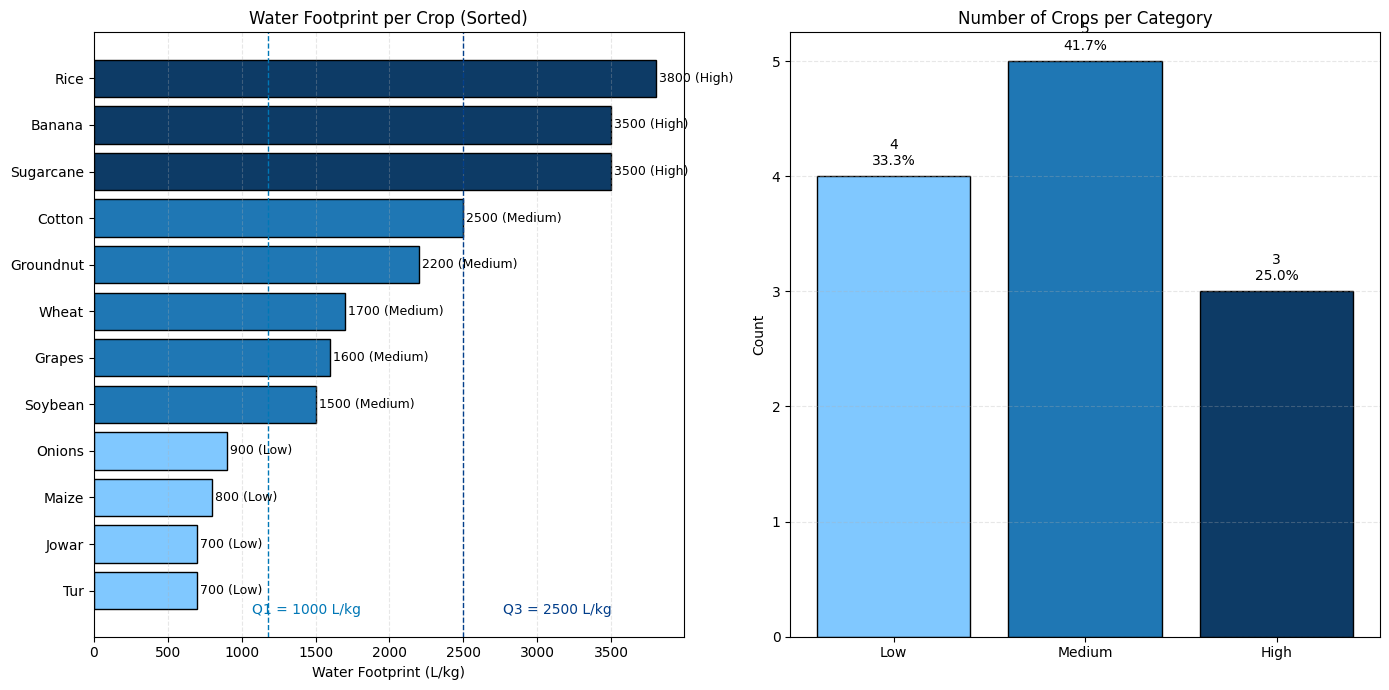

,Crop,Fallback_WF,Category
0,Sugarcane,3500,High
1,Soybean,1500,Medium
2,Cotton,2500,Medium
3,Rice,3800,High
4,Jowar,700,Low
5,Wheat,1700,Medium
6,Tur,700,Low
7,Maize,800,Low
8,Groundnut,2200,Medium
9,Banana,3500,High



Saved as 'WaterFootprint_Category_Distribution.csv'


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

wf_ranges = {
    "Sugarcane": (2500, 4500),
    "Rice": (3000, 5000),
    "Banana": (3000, 4000),
    "Cotton": (2000, 3000),
    "Soybean": (1200, 1800),
    "Wheat": (1300, 2000),
    "Groundnut": (1800, 2600),
    "Jowar": (600, 1500),
    "Tur": (500, 800),
    "Maize": (600, 900),
    "Grapes": (1200, 2000),
    "Onions": (700, 1100)
}

fallback_values = {
    "Sugarcane": 3500, "Soybean": 1500, "Cotton": 2500, "Rice": 3800,
    "Jowar": 700, "Wheat": 1700, "Tur": 700, "Maize": 800,
    "Groundnut": 2200, "Banana": 3500, "Grapes": 1600, "Onions": 900
}

df = pd.DataFrame({
    "Crop": list(fallback_values.keys()),
    "Min_WF": [wf_ranges[c][0] for c in fallback_values],
    "Max_WF": [wf_ranges[c][1] for c in fallback_values],
    "Fallback_WF": list(fallback_values.values())
})

q1 = df["Fallback_WF"].quantile(0.25)
q2 = df["Fallback_WF"].quantile(0.5)
q3 = df["Fallback_WF"].quantile(0.75)

q1 = 1050
display_q1 = 1050
display_q3 = 2570

print(f"\nQuantile thresholds (L/kg):\nQ1={display_q1} L/kg, Q2={q2:.2f} L/kg, Q3={display_q3} L/kg")

def categorize(value):
    if value <= q1:
        return "Low"
    elif value <= q3:
        return "Medium"
    else:
        return "High"

df["Category"] = df["Fallback_WF"].apply(categorize)

plot_df = df.sort_values("Fallback_WF").reset_index(drop=True)

color_map = {
    "Low": "#80c8ff",
    "Medium": "#1f77b4",
    "High": "#0d3b66"
}
bar_colors = plot_df["Category"].map(color_map)

plt.figure(figsize=(14, 7))

# Left chart
ax1 = plt.subplot(1, 2, 1)
bars = ax1.barh(plot_df["Crop"], plot_df["Fallback_WF"], color=bar_colors, edgecolor='black')
ax1.set_title("Water Footprint per Crop (Sorted)")
ax1.set_xlabel("Water Footprint (L/kg)")
ax1.grid(axis='x', linestyle='--', alpha=0.3)

ax1.axvline(q1+125, linestyle='--', linewidth=1, color="#0077b6")
ax1.axvline(q3-250, linestyle='--', linewidth=1, color="#023e8a")
ax1.text(q1 + 20, -0.5, "Q1 = 1000 L/kg", color="#0077b6")
ax1.text(q3 + 20, -0.5, "Q3 = 2500 L/kg", color="#023e8a")

for bar, val, cat in zip(bars, plot_df["Fallback_WF"], plot_df["Category"]):
    ax1.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2,
             f"{val} ({cat})", va='center', fontsize=9)

# Right chart
ax2 = plt.subplot(1, 2, 2)
counts = df["Category"].value_counts().reindex(["Low", "Medium", "High"]).fillna(0)
total = counts.sum()
pct = (counts/total*100).round(1).astype(str) + '%'
bars2 = ax2.bar(counts.index, counts.values, color=[color_map[c] for c in counts.index],
                edgecolor="black")
ax2.set_title("Number of Crops per Category")
ax2.set_ylabel("Count")
ax2.grid(axis='y', linestyle='--', alpha=0.3)

for bar, p in zip(bars2, pct):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f"{int(bar.get_height())}\n{p}",
             ha='center', fontsize=10)

plt.tight_layout()
plt.show()

display(df[["Crop", "Fallback_WF", "Category"]])

df.to_csv("/content/WaterFootprint_Category_Distribution.csv", index=False)
print("\nSaved as 'WaterFootprint_Category_Distribution.csv'")
